# Spar Buoy: Idealized Air/Water Forcing

This notebook demonstrates the `SparBuoySimple` model — a rigid vertical pole
that pierces the ocean surface. The submerged hull (length `draft`) feels
quadratic drag from the water; the column above the surface (`height_air`)
feels quadratic drag from the wind. The drag is sampled at a fixed number of
levels in each medium and averaged, so the steady-state drift is a
drag-weighted blend of the water current and the wind.

We use an idealized two-layer forcing — uniform water current below the surface
and uniform wind above it — and let the buoy integrate to steady state.

In [1]:
t_end = 900.0

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mechanical_drifters.models.spar_buoy_simple import (
    SparBuoyPhysics,
    SparBuoySimple,
)

## Model creation

`SparBuoySimple()` uses default physics. Here we compare the default drag
balance against a realistic one where the water drag dominates the (much
weaker) air drag, so the buoy tracks the water current closely.

In [3]:
drifter_default = SparBuoySimple(backend="numba")
print("Default physics:")
print(drifter_default.physics)

Default physics:
SparBuoyPhysics(m=1.0, m_tilde=1.0, k_air=10.0, k_water=10.0, draft=10.0, height_air=9.0, n_air=3, n_water=4)


In [4]:
drifter_realistic = SparBuoySimple(
    physics=SparBuoyPhysics(k_air=0.01, k_water=10),
    backend="numba",
)
print("Realistic physics:")
print(drifter_realistic.physics)

Realistic physics:
SparBuoyPhysics(m=1.0, m_tilde=1.0, k_air=0.01, k_water=10, draft=10.0, height_air=9.0, n_air=3, n_water=4)


## Idealized two-layer forcing

The sampler uses the model's z-positive-up convention: water below the surface
(`z <= 0`) carries the ocean current, air above (`z > 0`) carries the wind.

In [5]:
U_water = 0.3
V_water = 0.0

U_air = -5.0
V_air = 12.0

def sample_uv_air_water(z):
    z_arr = np.atleast_1d(np.asarray(z, dtype=float))
    U = np.where(z_arr <= 0, U_water, U_air)
    V = np.where(z_arr <= 0, V_water, V_air)
    return U, V

## Steady-state drift

With weak air drag relative to water drag, the steady-state drift sits close to
the water current despite the strong wind aloft.

In [6]:
t_out, Y_out, max_accel = drifter_realistic.integrate(
    sample_uv_air_water,
    t_span=(0.0, t_end),
)
drift_vel = drifter_realistic.drift_velocity(Y_out[-1])

xd_ss = float(drift_vel[0, 0])
yd_ss = float(drift_vel[0, 1])

print(f"Water current:         ({U_water:.3f}, {V_water:.3f}) m/s")
print(f"Wind:                  ({U_air:.3f}, {V_air:.3f}) m/s")
print(f"Steady-state drift:    ({xd_ss:.6f}, {yd_ss:.6f}) m/s")
print(f"Max residual accel:    {max_accel:.2e} m/s²")

Water current:         (0.300, 0.000) m/s
Wind:                  (-5.000, 12.000) m/s
Steady-state drift:    (0.137651, 0.367582) m/s
Max residual accel:    1.07e-03 m/s²


## Drift relative to the two forcing layers

The steady-state drift lies between the water current and the wind, pulled
strongly toward the water because the submerged hull dominates the drag balance.

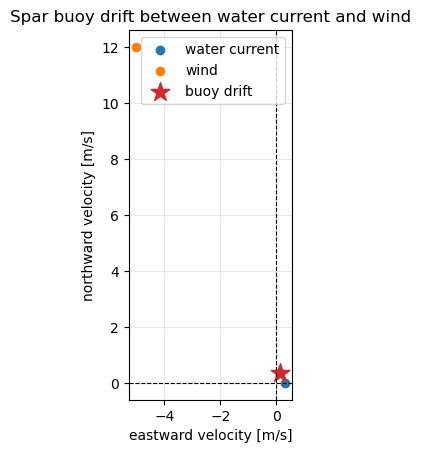

In [7]:
fig, ax = plt.subplots()
ax.scatter(U_water, V_water, color="C0", label="water current")
ax.scatter(U_air, V_air, color="C1", label="wind")
ax.scatter(xd_ss, yd_ss, color="C3", marker="*", s=200, label="buoy drift")
ax.axhline(0.0, color="k", linewidth=0.8, linestyle="--")
ax.axvline(0.0, color="k", linewidth=0.8, linestyle="--")
ax.set_xlabel("eastward velocity [m/s]")
ax.set_ylabel("northward velocity [m/s]")
ax.set_title("Spar buoy drift between water current and wind")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.show()